# Word-count threshold ablation for MMLU-PT

**Research question.** How do minimum and maximum question-length thresholds affect dataset retention and representation across exams and academic levels?

This notebook is a reproducible, distributional ablation designed to inform the `min_words` and `max_words` parameters of NeMo Curator's `WordCountFilter`. The study uses the dataset materialized immediately after structural MCQA validation and immediately before word-count filtering.

## Abstract

Length filtering can remove malformed fragments, but aggressive thresholds may discard valid short prompts or long passage-based questions and may disproportionately affect individual sources. We quantify these trade-offs through independent and joint threshold sweeps, subgroup retention analysis, and deterministic qualitative inspection of boundary cases. This is a coverage and sensitivity study: without semantic quality labels or downstream model evaluation, length alone cannot establish causal improvements in benchmark quality.

In [1]:
from __future__ import annotations

import hashlib
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from nemo_curator.stages.text.filters.heuristic import WordCountFilter

SEED = 42
MIN_THRESHOLDS = [0, 1, 2, 3, 4, 5, 8, 10, 15, 20, 30, 50]
MAX_THRESHOLDS = [100, 200, 300, 500, 750, 1_000, 1_500, 2_000, 3_000, 1_000_000]
NEUTRAL_MIN = 0
NEUTRAL_MAX = 1_000_000

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current directory.")

REPO_ROOT = find_repo_root(Path.cwd())
INPUT_DIR = REPO_ROOT / "output" / "03 - pre-word-filter"
print(f"Repository: {REPO_ROOT}")
print(f"Input: {INPUT_DIR}")
print(f"Python: {platform.python_version()}")

/home/aluno_paulosantana/repositories/mmlu-pt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-04 13:07:30,185	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Repository: /home/aluno_paulosantana/repositories/mmlu-pt
Input: /home/aluno_paulosantana/repositories/mmlu-pt/output/03 - pre-word-filter
Python: 3.12.3


## 1. Data and reproducibility

The input is the public-field projection produced after alternative, choice-count, and answer validation. Files are sorted before loading and hashing. The SHA-256 fingerprint identifies the exact materialized snapshot analyzed below.

In [2]:
EXPECTED_COLUMNS = [
    "exam",
    "exam_edition",
    "exam_url",
    "num",
    "question",
    "choices",
    "answer",
    "academic_level",
]

input_files = sorted(INPUT_DIR.glob("*.jsonl"))
if not input_files:
    raise FileNotFoundError(
        f"No JSONL files found in {INPUT_DIR}. Run src/mmlu_pt/pipeline_minimal.py first."
    )

frames = []
for path in input_files:
    frame = pd.read_json(path, lines=True, convert_dates=False)
    frame["_partition_file"] = path.name
    frames.append(frame)

data = pd.concat(frames, ignore_index=True)
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(data.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
if data.empty:
    raise ValueError("The pre-word-filter dataset is empty.")
if data["question"].isna().any():
    raise ValueError("The question field contains null values.")

digest = hashlib.sha256()
for path in input_files:
    digest.update(path.name.encode("utf-8"))
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)

snapshot = pd.Series(
    {
        "files": len(input_files),
        "records": len(data),
        "exams": data["exam"].nunique(),
        "exam_editions": data["exam_edition"].nunique(dropna=True),
        "academic_levels": data["academic_level"].nunique(),
        "sha256": digest.hexdigest(),
    },
    name="value",
)
display(snapshot.to_frame())

,value
files,19
records,41988
exams,17
exam_editions,1045
academic_levels,2
sha256,19c2e2b5bcab8fc6368766d41e6e2353f5c3d4416debdc008be76ad1fb318a4a


## 2. Measurement protocol

Word count is computed by the exact NeMo Curator implementation used by the pipeline. For Portuguese, version 1.3.0 strips leading/trailing whitespace and splits on whitespace. Threshold endpoints are inclusive: a record is retained when `min_words <= word_count <= max_words`.

In [3]:
word_counter = WordCountFilter(
    min_words=NEUTRAL_MIN,
    max_words=NEUTRAL_MAX,
    lang="pt",
)
data["word_count"] = data["question"].map(word_counter.score_document).astype(int)

neutral_mask = data["word_count"].between(NEUTRAL_MIN, NEUTRAL_MAX, inclusive="both")
assert neutral_mask.all(), "The configured neutral filter unexpectedly removes records."

percentiles = [0.001, 0.005, 0.01, 0.025, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
overall = data["word_count"].describe(percentiles=percentiles).to_frame("word_count").T
display(overall)

,count,mean,std,min,0.1%,0.5%,1%,2.5%,5%,10%,25%,50%,75%,90%,95%,97.5%,99%,99.5%,99.9%,max
word_count,"41,988.000",115.257,144.818,1.000,3.000,4.000,4.000,5.000,8.000,11.000,31.000,82.000,148.000,238.000,313.000,470.000,746.000,925.065,"1,625.078","2,620.000"


In [4]:
level_summary = (
    data.groupby("academic_level")["word_count"]
    .agg(records="size", mean="mean", median="median", minimum="min", maximum="max")
    .sort_values("records", ascending=False)
)
exam_summary = (
    data.groupby("exam")["word_count"]
    .agg(records="size", mean="mean", median="median", q95=lambda s: s.quantile(0.95), maximum="max")
    .sort_values("records", ascending=False)
)
display(Markdown("### Academic level"), level_summary)
display(Markdown("### Exam"), exam_summary)

### Academic level

,records,mean,median,minimum,maximum
academic_level,,,,,
undergraduate,31996,101.798,69.000,1,1023
high_school,9992,158.353,112.000,1,2620


### Exam

,records,mean,median,q95,maximum
exam,,,,,
ENADE,10793,161.267,152.000,317.000,772
OAB,10331,40.328,20.000,122.000,423
BNDES,4075,127.841,52.000,611.000,1023
ENEM,2689,111.795,104.000,219.000,400
OBI,2301,139.794,134.000,221.000,344
FUVEST,1662,102.867,76.000,270.850,835
RESIDENCIA_USP_UNICAMP,1575,46.766,28.000,137.300,344
POSCOMP,1311,59.429,46.000,155.500,345
REVALIDA,1195,109.109,100.000,202.000,436


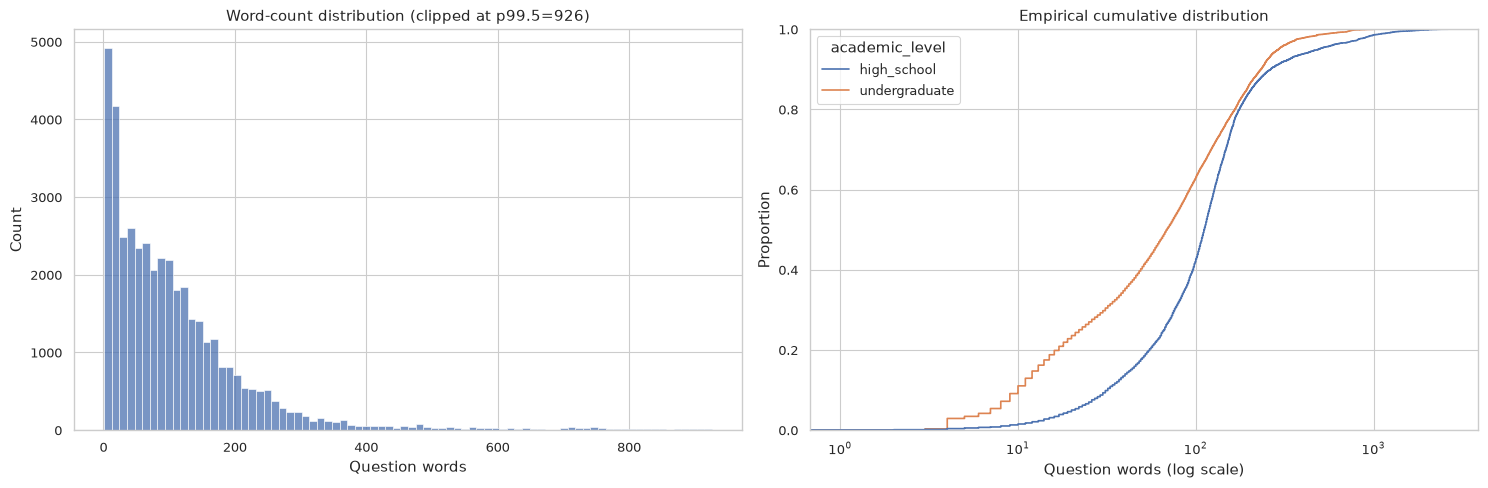

In [5]:
q995 = int(np.ceil(data["word_count"].quantile(0.995)))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=data[data["word_count"] <= q995], x="word_count", bins=80, ax=axes[0])
axes[0].set(title=f"Word-count distribution (clipped at p99.5={q995})", xlabel="Question words")
sns.ecdfplot(data=data, x="word_count", hue="academic_level", ax=axes[1])
axes[1].set(xscale="log", title="Empirical cumulative distribution", xlabel="Question words (log scale)")
plt.tight_layout()
plt.show()

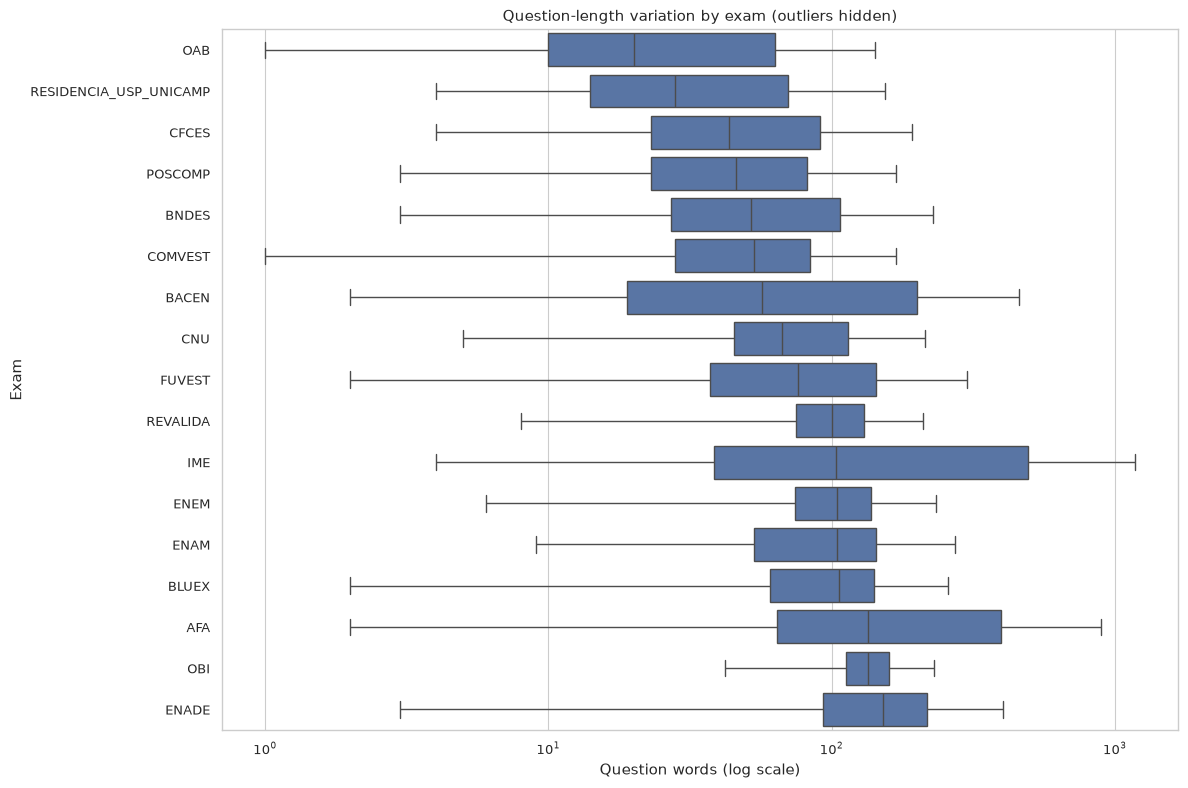

In [6]:
exam_order = exam_summary.sort_values("median").index
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=data,
    y="exam",
    x="word_count",
    order=exam_order,
    showfliers=False,
    color="#4C72B0",
)
plt.xscale("log")
plt.title("Question-length variation by exam (outliers hidden)")
plt.xlabel("Question words (log scale)")
plt.ylabel("Exam")
plt.tight_layout()
plt.show()

## 3. Tail inspection

Length extremes are not automatically errors. The tables below retain identifying metadata and a normalized preview so that fragments and legitimate passage-based questions can be distinguished manually.

In [7]:
def preview_table(frame: pd.DataFrame, limit: int | None = None) -> pd.DataFrame:
    result = frame[["exam", "exam_edition", "num", "academic_level", "word_count", "question"]].copy()
    result["question"] = result["question"].str.replace(r"\s+", " ", regex=True).str.strip().str.slice(0, 240)
    return result.head(limit) if limit is not None else result

shortest = data.sort_values(["word_count", "exam", "exam_edition", "num"])
longest = data.sort_values(["word_count", "exam"], ascending=[False, True])
display(Markdown("### Twenty shortest questions"), preview_table(shortest, 20))
display(Markdown("### Twenty longest questions"), preview_table(longest, 20))

### Twenty shortest questions

,exam,exam_edition,num,academic_level,word_count,question
27728,COMVEST,COMVEST 2014,14,high_school,1,Assinale
27901,COMVEST,COMVEST 2016,49,high_school,1,Considere
11817,OAB,OAB-SP 2003.3,80,undergraduate,1,Imunidade:
28632,AFA,AFA_2016,33,high_school,2,The text
28807,AFA,AFA_2019,33,high_school,2,Cancer is
28811,AFA,AFA_2019,37,high_school,2,The text
35414,BACEN,Analista de Finanças - Conhecimentos Específicos - 2006,22,undergraduate,2,A tentativa
35638,BACEN,Analista de Sistemas - Conhecimentos Específicos - 2006,34,undergraduate,2,"No RUP,"
35847,BACEN,Procurador - Conhecimentos Específicos - 2002,39,undergraduate,2,Preempção é:
36445,BLUEX,USP_2018,65,high_school,2,"Nesse texto,"


### Twenty longest questions

,exam,exam_edition,num,academic_level,word_count,question
13223,IME,IME 2021 - Portugues,20,high_school,2620,"ENGENHEIROS DA VITÓRIA Solução de problemas na história [...] Quando se fala na eficiência em conseguir equipamentos de combate e transferir combatentes de A para B, os britâni..."
13420,IME,IME 2024 - Portugues,20,high_school,2382,"Texto 1 O IMORTAL MEU PAI NASCEU em 1600... Perdão, em 1800, naturalmente... Não, senhor, replicou o dr. Leão, de um modo grave e triste; foi em 1600. Estupefação dos ouvintes,..."
13289,IME,IME 2022 - Portugues,15,high_school,2377,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
13290,IME,IME 2022 - Portugues,16,high_school,2348,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
13412,IME,IME 2024 - Portugues,12,high_school,2338,"Texto 1 O IMORTAL MEU PAI NASCEU em 1600... Perdão, em 1800, naturalmente... Não, senhor, replicou o dr. Leão, de um modo grave e triste; foi em 1600. Estupefação dos ouvintes,..."
13287,IME,IME 2022 - Portugues,13,high_school,2259,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
13288,IME,IME 2022 - Portugues,14,high_school,2259,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
12626,IME,IME 2012 - Portugues,10,high_school,2212,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
12623,IME,IME 2012 - Portugues,7,high_school,2209,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
12625,IME,IME 2012 - Portugues,9,high_school,2107,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...


## 4. Threshold ablation

We report total retention, academic-level retention, the least-retained exam, and the maximum absolute change in exam prevalence. The latter measures representation shift in percentage points relative to the unfiltered population. Small exams should be interpreted together with their sample sizes.

In [8]:
baseline_exam_share = data["exam"].value_counts(normalize=True)
baseline_exam_size = data["exam"].value_counts()
baseline_level_size = data["academic_level"].value_counts()

def threshold_metrics(min_words: int, max_words: int) -> dict[str, float | int]:
    mask = data["word_count"].between(min_words, max_words, inclusive="both")
    retained = data.loc[mask]
    exam_retention = retained["exam"].value_counts().reindex(baseline_exam_size.index, fill_value=0) / baseline_exam_size
    retained_exam_share = retained["exam"].value_counts(normalize=True).reindex(baseline_exam_share.index, fill_value=0)
    level_retention = retained["academic_level"].value_counts().reindex(baseline_level_size.index, fill_value=0) / baseline_level_size
    return {
        "min_words": min_words,
        "max_words": max_words,
        "retained": int(mask.sum()),
        "removed": int((~mask).sum()),
        "retention_pct": 100 * mask.mean(),
        "high_school_retention_pct": 100 * level_retention.get("high_school", np.nan),
        "undergraduate_retention_pct": 100 * level_retention.get("undergraduate", np.nan),
        "worst_exam_retention_pct": 100 * exam_retention.min(),
        "worst_exam": str(exam_retention.idxmin()),
        "max_exam_share_shift_pp": 100 * (retained_exam_share - baseline_exam_share).abs().max(),
    }

minimum_ablation = pd.DataFrame(
    threshold_metrics(minimum, NEUTRAL_MAX) for minimum in MIN_THRESHOLDS
)
maximum_ablation = pd.DataFrame(
    threshold_metrics(NEUTRAL_MIN, maximum) for maximum in MAX_THRESHOLDS
)
display(Markdown("### Minimum-threshold ablation"), minimum_ablation)
display(Markdown("### Maximum-threshold ablation"), maximum_ablation)

### Minimum-threshold ablation

,min_words,max_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp
0,0,1000000,41988,0,100.000,100.000,100.000,100.000,ENADE,0.000
1,1,1000000,41988,0,100.000,100.000,100.000,100.000,ENADE,0.000
2,2,1000000,41985,3,99.993,99.980,99.997,99.566,COMVEST,0.005
3,3,1000000,41968,20,99.952,99.920,99.962,99.349,COMVEST,0.012
4,4,1000000,41883,105,99.750,99.850,99.719,98.698,COMVEST,0.113
5,5,1000000,41030,958,97.718,99.650,97.115,91.859,OAB,1.475
6,8,1000000,40196,1792,95.732,99.239,94.637,85.906,OAB,2.525
7,10,1000000,38952,3036,92.769,98.729,90.908,76.817,OAB,4.231
8,15,1000000,36121,5867,86.027,97.258,82.520,59.471,OAB,7.595
9,20,1000000,34243,7745,81.554,95.426,77.222,50.692,OAB,9.311


### Maximum-threshold ablation

,min_words,max_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp
0,0,100,24448,17540,58.226,42.644,63.092,12.299,OBI,13.448
1,0,200,36014,5974,85.772,84.327,86.223,57.532,IME,4.685
2,0,300,39695,2293,94.539,91.543,95.474,63.702,IME,1.414
3,0,500,41071,917,97.816,95.126,98.656,75.227,IME,0.606
4,0,750,41579,409,99.026,96.998,99.659,82.305,IME,0.443
5,0,1000,41836,152,99.638,98.569,99.972,88.022,IME,0.306
6,0,1500,41939,49,99.883,99.510,100.000,95.554,IME,0.114
7,0,2000,41968,20,99.952,99.800,100.000,98.185,IME,0.046
8,0,3000,41988,0,100.000,100.000,100.000,100.000,ENADE,0.000
9,0,1000000,41988,0,100.000,100.000,100.000,100.000,ENADE,0.000


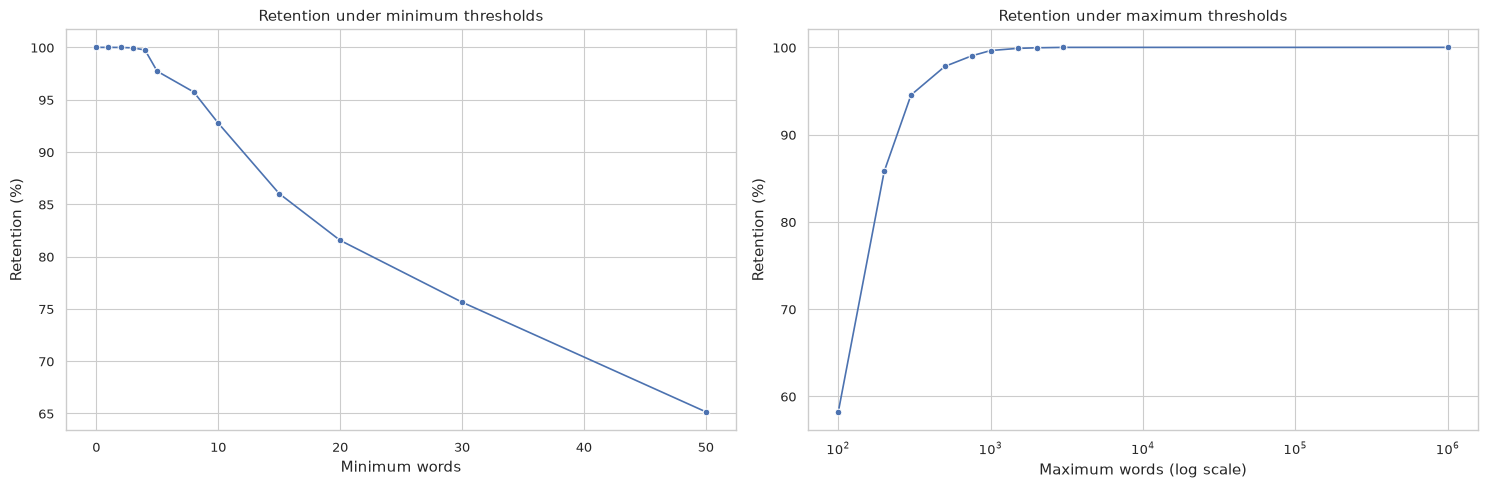

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=minimum_ablation, x="min_words", y="retention_pct", marker="o", ax=axes[0])
axes[0].set(title="Retention under minimum thresholds", xlabel="Minimum words", ylabel="Retention (%)")
sns.lineplot(data=maximum_ablation, x="max_words", y="retention_pct", marker="o", ax=axes[1])
axes[1].set(xscale="log", title="Retention under maximum thresholds", xlabel="Maximum words (log scale)", ylabel="Retention (%)")
plt.tight_layout()
plt.show()

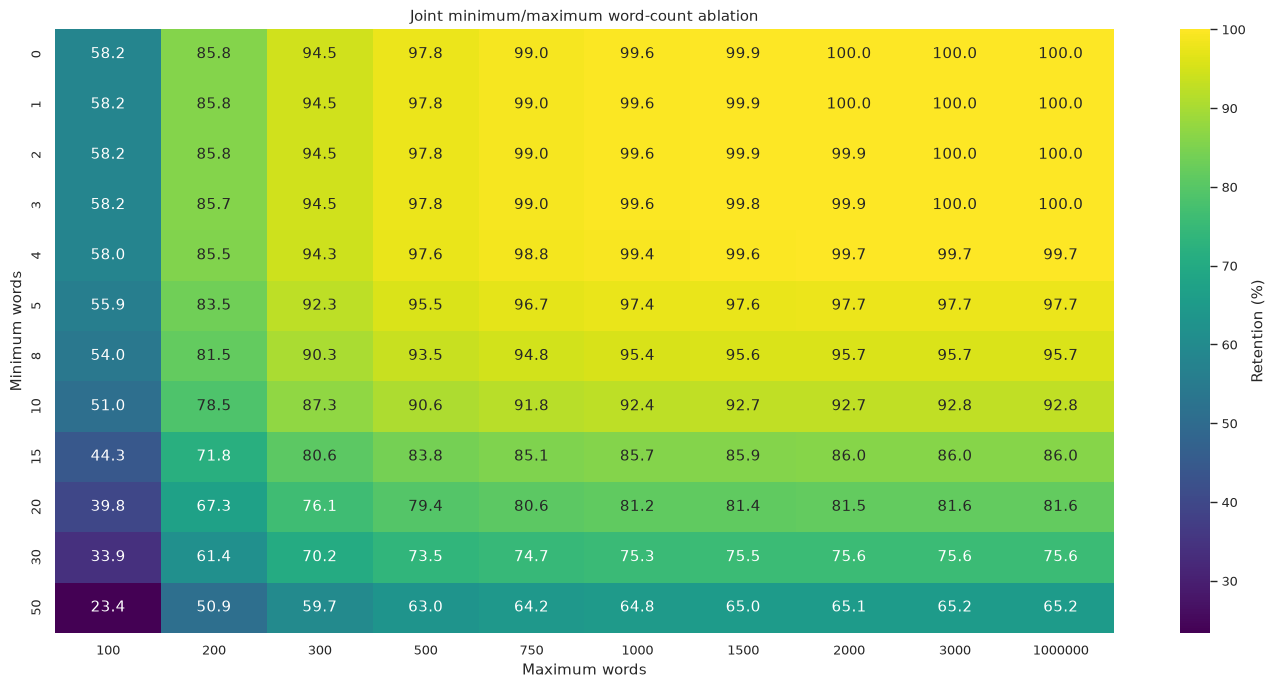

In [10]:
joint_rows = [
    threshold_metrics(minimum, maximum)
    for minimum in MIN_THRESHOLDS
    for maximum in MAX_THRESHOLDS
    if minimum <= maximum
]
joint_ablation = pd.DataFrame(joint_rows)
retention_grid = joint_ablation.pivot(index="min_words", columns="max_words", values="retention_pct")

plt.figure(figsize=(14, 7))
sns.heatmap(retention_grid, annot=True, fmt=".1f", cmap="viridis", cbar_kws={"label": "Retention (%)"})
plt.title("Joint minimum/maximum word-count ablation")
plt.xlabel("Maximum words")
plt.ylabel("Minimum words")
plt.tight_layout()
plt.show()

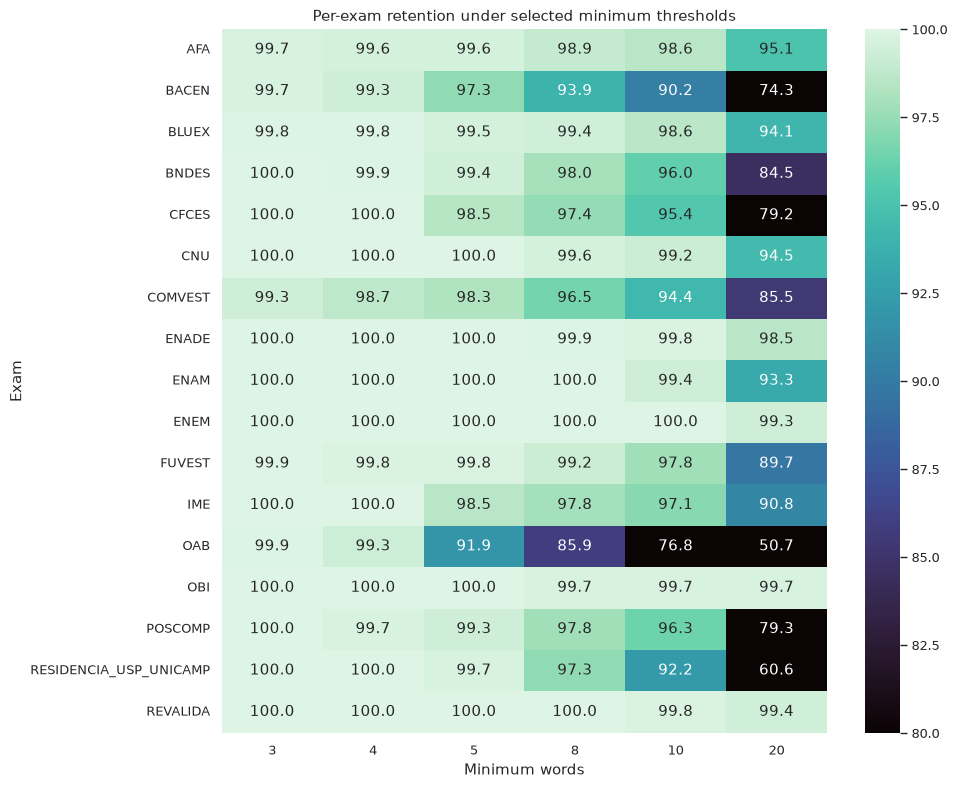

In [11]:
selected_minima = [3, 4, 5, 8, 10, 20]
exam_min_retention = pd.DataFrame(
    {
        minimum: (
            data.loc[data["word_count"] >= minimum, "exam"].value_counts().reindex(baseline_exam_size.index, fill_value=0)
            / baseline_exam_size
            * 100
        )
        for minimum in selected_minima
    }
).sort_index()

plt.figure(figsize=(10, 8))
sns.heatmap(exam_min_retention, annot=True, fmt=".1f", cmap="mako", vmin=80, vmax=100)
plt.title("Per-exam retention under selected minimum thresholds")
plt.xlabel("Minimum words")
plt.ylabel("Exam")
plt.tight_layout()
plt.show()

## 5. Deterministic boundary audit

The following samples support qualitative review. They are deterministic and stratified by length bands. They should be used to assess whether removals are malformed fragments, valid concise prompts, or valid long contexts.

In [12]:
def deterministic_sample(frame: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    if frame.empty:
        return preview_table(frame)
    return preview_table(frame.sample(n=min(n, len(frame)), random_state=SEED).sort_values(["word_count", "exam"]))

short_bands = {
    "1-2 words": data[data["word_count"].between(1, 2)],
    "3 words": data[data["word_count"] == 3],
    "4 words": data[data["word_count"] == 4],
    "5 words": data[data["word_count"] == 5],
}
for label, frame in short_bands.items():
    display(Markdown(f"### {label}: {len(frame):,} records"), deterministic_sample(frame))

long_bands = {
    "501-1,000 words": data[data["word_count"].between(501, 1_000)],
    "1,001-2,000 words": data[data["word_count"].between(1_001, 2_000)],
    "More than 2,000 words": data[data["word_count"] > 2_000],
}
for label, frame in long_bands.items():
    display(Markdown(f"### {label}: {len(frame):,} records"), deterministic_sample(frame))

### 1-2 words: 20 records

,exam,exam_edition,num,academic_level,word_count,question
35638,BACEN,Analista de Sistemas - Conhecimentos Específicos - 2006,34,undergraduate,2,"No RUP,"
27965,COMVEST,COMVEST 2017,23,high_school,2,Seja 𝑖
30966,FUVEST,Fuvest 2002 - Segundo Dia,21,high_school,2,Os vírus
5833,OAB,OAB-SP 2008.3,9,undergraduate,2,O CNJ
7846,OAB,OAB-RJ 2007.1,69,undergraduate,2,A desapropriação
12308,OAB,OAB-MG 2001.3,30,undergraduate,2,Considera-se empregador::
11049,OAB,OAB-SP 2004.3,88,undergraduate,2,"A isenção,"
9531,OAB,OAB-RS 2006.3,18,undergraduate,2,A compensação


### 3 words: 85 records

,exam,exam_edition,num,academic_level,word_count,question
28293,AFA,AFA_2011,30,high_school,3,The first boy
35962,BACEN,Procurador - Conhecimentos Específicos II - 2006,54,undergraduate,3,Os crimes culposos
38379,BNDES,BNDES 2002 - Advogado,16,undergraduate,3,"Nos contratos bancários,"
5478,OAB,OAB-BR 2010.1,45,undergraduate,3,A ação rescisória
8734,OAB,OAB-MG 2006.3,69,undergraduate,3,O nome empresarial:
7586,OAB,OAB-SP 2006.3,1,undergraduate,3,Caracteriza ato complexo
7323,OAB,OAB-MG 2007.1,35,undergraduate,3,É CORRETO afirmar:
8164,OAB,OAB-RS 2007.2,93,undergraduate,3,"Na execução fiscal,"


### 4 words: 853 records

...

,exam,exam_edition,num,academic_level,word_count,question
13434,IME,IME 2024 - Portugues,35,high_school,501,Text 2 Drones Could Spot Crime Scenes from Afar A system could aid forensic searches and crime-scene mapping by detecting reflections from human materials BY RACHEL BERKOWITZ V...
29021,AFA,AFA_2023,4,high_school,615,"TEXTO: TEXTO II A seguir, você lerá um trecho do livro Viagens de Gulliver, um clássico da literatura universal, escrito por Jonathan Swift, publicado em 1726. O trecho foi ext..."
40231,BNDES,BNDES 2009 - Técnico em Arquivo,31,undergraduate,615,"Texto I EL PAÍS.com Deportes ""Adiós a nuestro complejo de perros callejeros"" Los brasileños consideran, como destaca Lula, que ya son ""ciudadanos respetados del mundo"" Tras las..."
28407,AFA,AFA_2012,70,high_school,710,"TEXTO: TEXT I BRAZILIAN AIR FORCE ACADEMY AFA (Air Force Academy), located at Pirassununga, State of São Paulo, is responsible for the training of Pilots, Administrative and Ae..."
40276,BNDES,BNDES 2010 - Profissional Básico Análise de Sistemas e Suporte,26,undergraduate,728,"The importance of discovering your plan B By John W. Mullins and Randy Komisar If the founders of Google, Starbucks, or PayPal had stuck to their original business plans, we'd ..."
28613,AFA,AFA_2016,14,high_school,849,"TEXTO: TEXTO I RETRATO Eu não tinha este rosto de hoje, Assim calmo, assim triste, assim magro, Nem estes olhos tão vazios, Nem o lábio amargo 5 Eu não tinha estas mãos sem for..."
28900,AFA,AFA_2021,7,high_school,947,"TEXTO: TEXT When making a decision, it is a common impulse to look and see what others are doing. Nevertheless, it is often unclear whether the path that everyone else may be f..."
41518,BNDES,BNDES 2024 - Analista Administração (manhã),21,undergraduate,989,"O consumo como forma de expressão e de pertencimento Você é o que você consome, queira ou não, sendo consumista ou não. Dentro da lógica capitalista, a exemplo da frase dita pe..."


### 1,001-2,000 words: 132 records

,exam,exam_edition,num,academic_level,word_count,question
39748,BNDES,BNDES 2008 - Administração,27,undergraduate,1001,"Estilo casual La tendencia se afirma en las oficinas, pero con reglas La moda informal gana seguidores en las oficinas. Una tendencia que comenzó en Estados Unidos a fines de l..."
13148,IME,IME 2020 - Portugues,11,high_school,1044,"Texto 1 CAPÍTULO 3 A GUERRA DAS CAATINGAS Os doutores na arte de matar que hoje, na Europa, invadem escandalosamente a ciência, perturbando-lhe o remanso com um retinir de espo..."
28760,AFA,AFA_2018,46,high_school,1047,TEXTO: TEXT WHY DO SUPERVILLAINS FASCINATE US? A PSYCHOLOGICAL PERSPECTIVE Why are we fascinated by supervillains? Posing the question is much like asking why evil itself intri...
13281,IME,IME 2022 - Portugues,7,high_school,1368,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
12880,IME,IME 2016 - Portugues,4,high_school,1574,"Texto 1 A CRISE AMBIENTAL Benedito Braga Segundo Miller (1985), nosso planeta pode ser comparado a uma astronave que dispõe de um eficiente sistema de aproveitamento de energia..."
12959,IME,IME 2017 - Portugues,18,high_school,1670,"A CONDIÇÃO HUMANA A Vita Activa e a Condição Humana Com a expressão vita activa, pretendo designar três atividades humanas fundamentais: labor, trabalho e ação. Trata-se de ati..."
13243,IME,IME 2021 - Portugues,40,high_school,1709,"Chariot Rodrigo Quijada Plubins Definition The chariot was a light vehicle, usually on two wheels, drawn by one or more horses, often carrying two standing persons, a driver an..."
13151,IME,IME 2020 - Portugues,14,high_school,1792,"Texto 1 CAPÍTULO 3 A GUERRA DAS CAATINGAS Os doutores na arte de matar que hoje, na Europa, invadem escandalosamente a ciência, perturbando-lhe o remanso com um retinir de espo..."


### More than 2,000 words: 20 records

,exam,exam_edition,num,academic_level,word_count,question
12622,IME,IME 2012 - Portugues,6,high_school,2007,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
12630,IME,IME 2012 - Portugues,14,high_school,2028,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
12620,IME,IME 2012 - Portugues,4,high_school,2037,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
12618,IME,IME 2012 - Portugues,2,high_school,2044,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
12617,IME,IME 2012 - Portugues,1,high_school,2051,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
12626,IME,IME 2012 - Portugues,10,high_school,2212,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
13288,IME,IME 2022 - Portugues,14,high_school,2259,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
13290,IME,IME 2022 - Portugues,16,high_school,2348,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."


In [13]:
candidate_pairs = [
    (0, 1_000_000),
    (1, 1_000_000),
    (2, 1_000_000),
    (3, 1_000_000),
    (4, 1_000_000),
    (5, 1_000_000),
    (4, 2_000),
    (4, 1_000),
    (4, 500),
]
candidate_comparison = pd.DataFrame(
    threshold_metrics(minimum, maximum) for minimum, maximum in candidate_pairs
)
display(Markdown("## 6. Candidate configurations"), candidate_comparison)

## 6. Candidate configurations

,min_words,max_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp
0,0,1000000,41988,0,100.000,100.000,100.000,100.000,ENADE,0.000
1,1,1000000,41988,0,100.000,100.000,100.000,100.000,ENADE,0.000
2,2,1000000,41985,3,99.993,99.980,99.997,99.566,COMVEST,0.005
3,3,1000000,41968,20,99.952,99.920,99.962,99.349,COMVEST,0.012
4,4,1000000,41883,105,99.750,99.850,99.719,98.698,COMVEST,0.113
5,5,1000000,41030,958,97.718,99.650,97.115,91.859,OAB,1.475
6,4,2000,41863,125,99.702,99.650,99.719,98.185,IME,0.101
7,4,1000,41731,257,99.388,98.419,99.691,88.022,IME,0.300
8,4,500,40966,1022,97.566,94.976,98.375,75.227,IME,0.601


In [14]:
short_counts = data["word_count"].value_counts().sort_index()
long_count_1000 = int((data["word_count"] > 1_000).sum())
long_count_2000 = int((data["word_count"] > 2_000).sum())
display(
    Markdown(
        f"""## Evidence summary

- Baseline population: **{len(data):,}** structurally valid questions.
- Questions with at most 2 words: **{int((data['word_count'] <= 2).sum()):,}**.
- Questions with at most 3 words: **{int((data['word_count'] <= 3).sum()):,}**.
- Questions longer than 1,000 words: **{long_count_1000:,}**.
- Questions longer than 2,000 words: **{long_count_2000:,}**.

Threshold selection must combine these coverage results with the boundary audit above."""
    )
)

## Evidence summary

- Baseline population: **41,988** structurally valid questions.
- Questions with at most 2 words: **20**.
- Questions with at most 3 words: **105**.
- Questions longer than 1,000 words: **152**.
- Questions longer than 2,000 words: **20**.

Threshold selection must combine these coverage results with the boundary audit above.

## 7. Threats to validity

1. **No semantic labels.** Retention is not equivalent to quality; the audit can reveal obvious fragments but does not estimate annotation error rates.
2. **No downstream evaluation.** This study does not measure effects on model accuracy, calibration, or robustness.
3. **Whitespace-based words.** The Curator metric is intentionally reproduced, but it is not a model tokenizer and does not predict context-window usage exactly.
4. **Source imbalance.** Large exams dominate aggregate statistics; subgroup results must accompany global retention.
5. **Passage-based questions.** Long shared source texts may be repeated across several questions and should not be treated as malformed solely because they are outliers.

The final configuration should therefore choose a lower bound supported by fragment inspection and treat any upper bound as an operational coverage decision rather than a semantic-quality guarantee.

## 8. Conclusion and selected operating point

Based on the quantitative ablation and the manual boundary inspection, the selected configuration is **`min_words=4` and `max_words=1_000`**. Both endpoints are inclusive under NeMo Curator's `WordCountFilter`.

The lower threshold excludes the 105 records containing only one to three words. Manual inspection showed that this extreme lower tail has the greatest concentration of prompts that appear truncated, underspecified, or compatible with OCR and extraction failures. In contrast, the four-word boundary contains concise but structurally complete MCQA formulations, such as imperative prompts asking the reader to select the correct or incorrect alternative. Some shorter stems can still be completed by their answer choices, so this threshold deliberately favors structural reliability over retaining every terse formulation; it should not be interpreted as proof that every removed item is semantically invalid.

The upper threshold is supported by the empirical distribution: the 99th percentile is 746 words and the 99.5th percentile is approximately 925 words. A 1,000-word ceiling therefore lies above more than 99.5% of the corpus while excluding the most extreme length tail. Applied alone, it removes 152 records (0.362%). The long-tail audit shows that several excluded items contain genuine passage-based material, especially from IME, so this cutoff is justified as an operational decision to control unusually large examples, repeated source passages, and processing cost—not as evidence that texts above 1,000 words are intrinsically low quality.

Together, the selected thresholds retain **41,731 of 41,988 records (99.388%)** and remove **257 records (0.612%)**. Retention is 98.419% for high-school questions and 99.691% for undergraduate questions. The largest source-specific effect occurs for IME, which retains 970 of 1,102 records (88.022%); this expected asymmetry follows from its unusually long passage-based questions and should be monitored in downstream experiments.

The selected operating point is therefore:

```python
WordCountFilter(min_words=4, max_words=1_000, lang="pt")
```

This conclusion is supported by corpus coverage and manual structural inspection. It remains a filtering policy rather than a semantic-quality result: downstream evaluation or formal human annotation would be required to determine whether the removed tail improves benchmark validity or model performance.